In [ ]:

import pandas as pd


df = pd.read_csv("/Users/shikhachaudhary/Desktop/Data Analytics Projects /Logistic and Linear Regression/WA_Fn-UseC_-HR-Employee-Attrition.csv")

# Basic checks
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nAttrition split:")
print(df['Attrition'].value_counts())
print("\nSalary stats:")
print(df['MonthlyIncome'].describe())

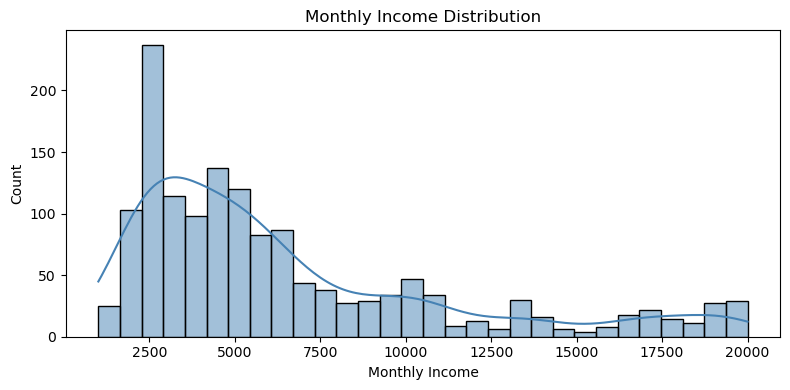

/var/folders/n2/2z1lpcqn3dx8ywr6258cvn4w0000gn/T/ipykernel_4794/456737545.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attrition', data=df, palette='Set2')


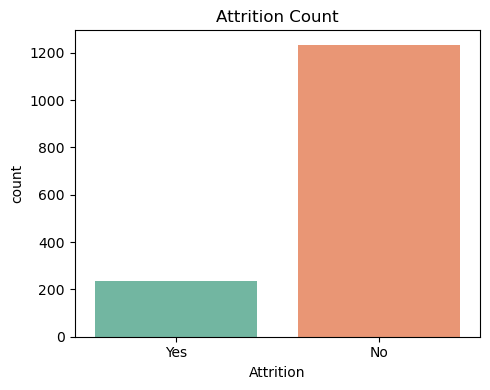

/var/folders/n2/2z1lpcqn3dx8ywr6258cvn4w0000gn/T/ipykernel_4794/456737545.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, palette='Set2')


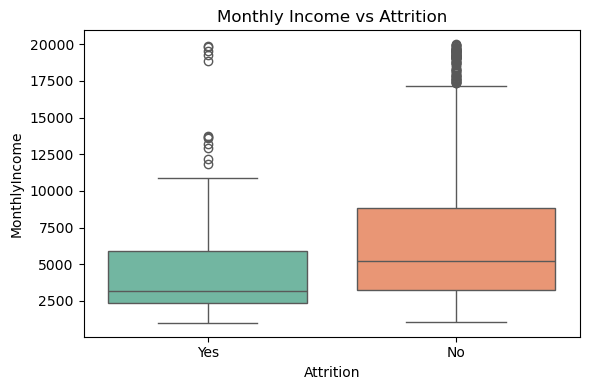

/var/folders/n2/2z1lpcqn3dx8ywr6258cvn4w0000gn/T/ipykernel_4794/456737545.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Department', y='AttritionRate', data=dept_attr, palette='Set2')


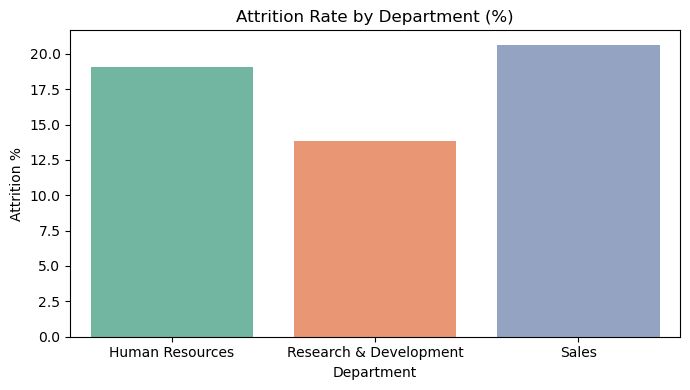

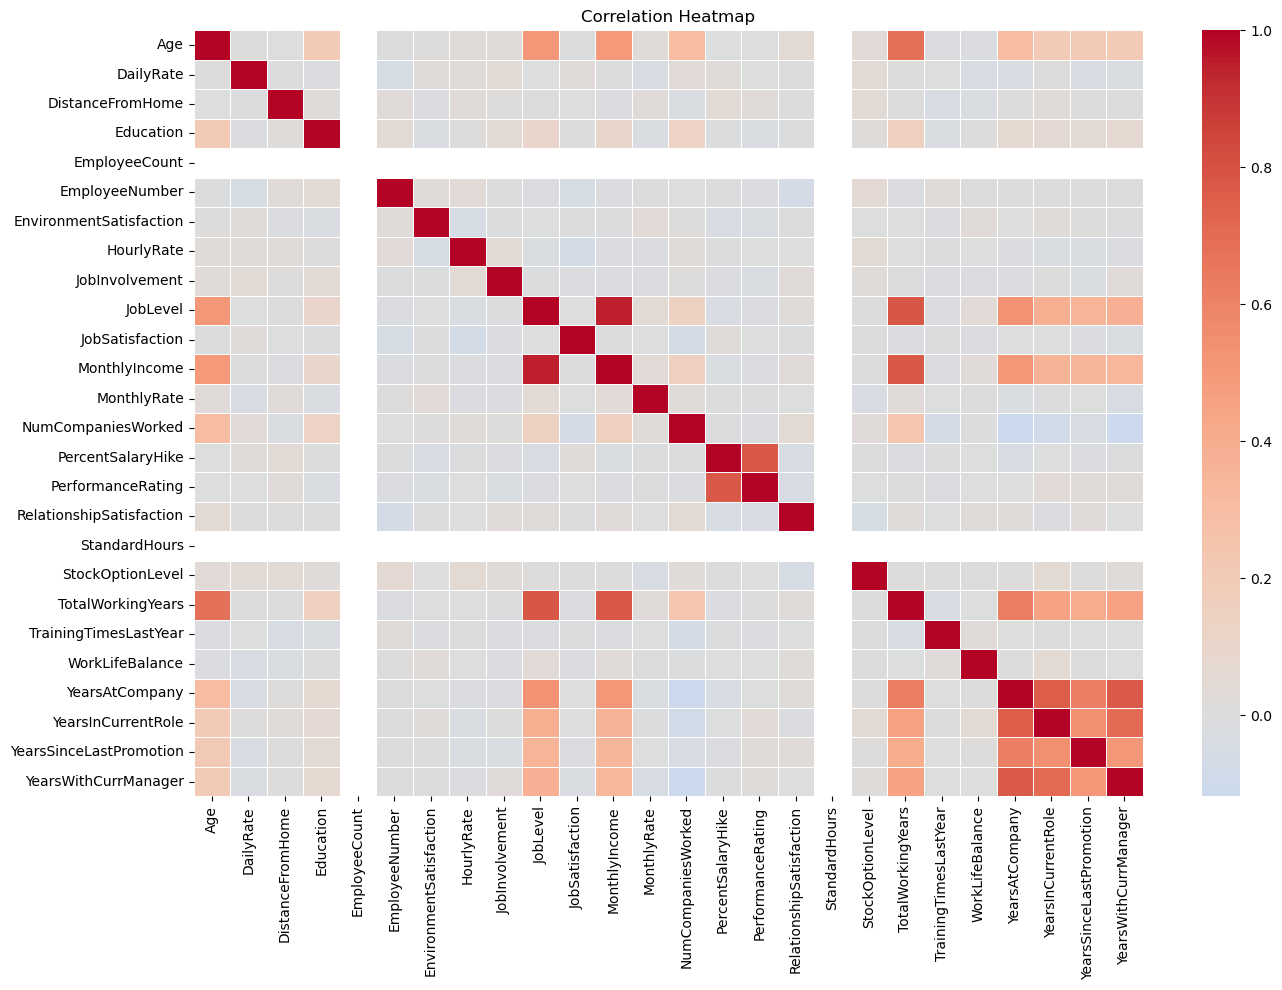

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. Salary distribution ──────────────────────────────
plt.figure(figsize=(8, 4))
sns.histplot(df['MonthlyIncome'], bins=30, kde=True, color='steelblue')
plt.title('Monthly Income Distribution')
plt.xlabel('Monthly Income')
plt.tight_layout()
plt.show()

# ── 2. Attrition count ──────────────────────────────────
plt.figure(figsize=(5, 4))
sns.countplot(x='Attrition', data=df, palette='Set2')
plt.title('Attrition Count')
plt.tight_layout()
plt.show()

# ── 3. Salary by Attrition ──────────────────────────────
plt.figure(figsize=(6, 4))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, palette='Set2')
plt.title('Monthly Income vs Attrition')
plt.tight_layout()
plt.show()

# ── 4. Attrition rate by Department ─────────────────────
plt.figure(figsize=(7, 4))
dept_attr = df.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
dept_attr.columns = ['Department', 'AttritionRate']
sns.barplot(x='Department', y='AttritionRate', data=dept_attr, palette='Set2')
plt.title('Attrition Rate by Department (%)')
plt.ylabel('Attrition %')
plt.tight_layout()
plt.show()

# ── 5. Correlation heatmap (numeric columns only) ────────
plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0,
            linewidths=0.4, annot=False)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

Step 3 — Preprocessing

In [5]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

# ── 1. Drop useless columns ──────────────────────────────
df_model.drop(['EmployeeCount', 'EmployeeNumber', 
               'StandardHours', 'Over18'], axis=1, inplace=True)

# ── 2. Encode Attrition → 0/1 ────────────────────────────
df_model['Attrition'] = df_model['Attrition'].map({'Yes': 1, 'No': 0})

# ── 3. Label Encoding (ordered/binary columns) ───────────
ordinal_cols = ['BusinessTravel', 'OverTime']
le = LabelEncoder()
for col in ordinal_cols:
    df_model[col] = le.fit_transform(df_model[col])

print("Label Encoded columns:", ordinal_cols)
print("\nBusinessTravel mapping:", 
      dict(zip(df['BusinessTravel'], df_model['BusinessTravel'])))
print("OverTime mapping:", 
      dict(zip(df['OverTime'], df_model['OverTime'])))

# ── 4. One Hot Encoding (nominal/no-order columns) ────────
nominal_cols = ['Department', 'EducationField', 
                'Gender', 'JobRole', 'MaritalStatus']
df_model = pd.get_dummies(df_model, columns=nominal_cols, drop_first=True)

print("\nShape after One Hot Encoding:", df_model.shape)

# ── 5. Log transform MonthlyIncome (fix skewness) ─────────
df_model['MonthlyIncome_log'] = np.log(df_model['MonthlyIncome'])

# ── 6. Verify final dataframe ─────────────────────────────
print("\nFinal shape:", df_model.shape)
print("\nColumn list:")
print(list(df_model.columns))
print("\nFirst 3 rows:")
print(df_model.head(3))
print("\nAny nulls?", df_model.isnull().sum().sum())

Label Encoded columns: ['BusinessTravel', 'OverTime']

BusinessTravel mapping: {'Travel_Rarely': 2, 'Travel_Frequently': 1, 'Non-Travel': 0}
OverTime mapping: {'Yes': 1, 'No': 0}

Shape after One Hot Encoding: (1470, 44)

Final shape: (1470, 45)

Column list:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'Gender_Male', 'JobRole_Human Resources', 'JobRole_

Training size: (1176, 42)
Testing size : (294, 42)

R² Score : 0.8574
RMSE     : 0.2368

Top 10 features driving salary:
                          Feature  Coefficient
     JobRole_Sales Representative    -0.415479
                         JobLevel     0.359783
    JobRole_Laboratory Technician    -0.350733
       JobRole_Research Scientist    -0.334381
        JobRole_Research Director     0.189405
                  JobRole_Manager     0.187675
          JobRole_Human Resources    -0.145361
Department_Research & Development     0.108320
                 Department_Sales     0.081052
                PerformanceRating    -0.046530


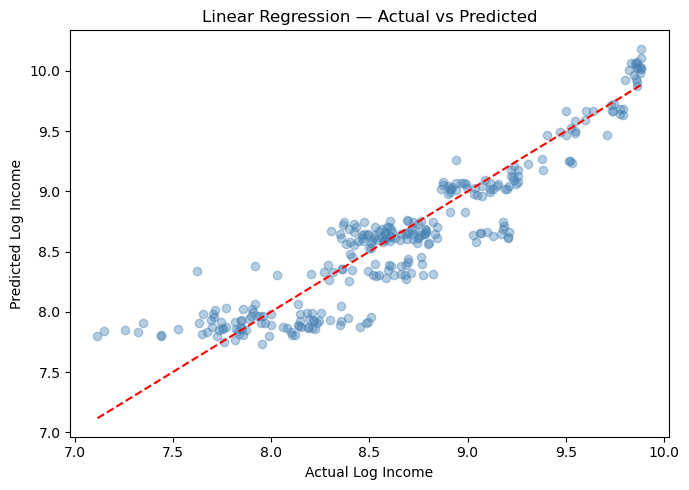

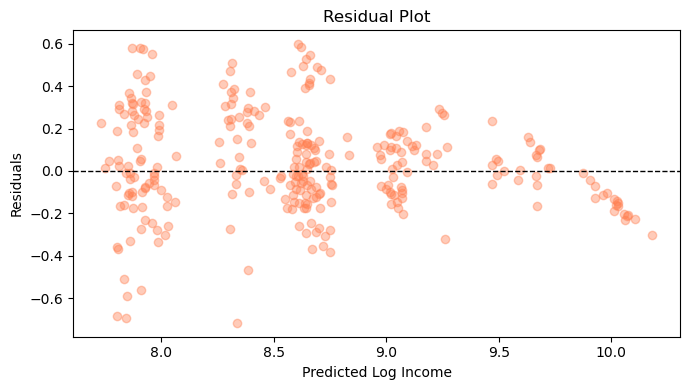

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# ── 1. Define features and target ────────────────────────
# Drop both income columns from features
X = df_model.drop(['MonthlyIncome', 'MonthlyIncome_log', 'Attrition'], axis=1)
y = df_model['MonthlyIncome_log']

# ── 2. Train/Test split ───────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size :", X_test.shape)

# ── 3. Train the model ────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train, y_train)

# ── 4. Predictions ────────────────────────────────────────
y_pred = lr.predict(X_test)

# ── 5. Evaluate ───────────────────────────────────────────
r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nR² Score : {r2:.4f}")
print(f"RMSE     : {rmse:.4f}")

# ── 6. Top 10 most influential features ───────────────────
coef_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nTop 10 features driving salary:")
print(coef_df.head(10).to_string(index=False))

# ── 7. Actual vs Predicted plot ───────────────────────────
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
plt.xlabel('Actual Log Income')
plt.ylabel('Predicted Log Income')
plt.title('Linear Regression — Actual vs Predicted')
plt.tight_layout()
plt.show()

# ── 8. Residual plot ──────────────────────────────────────
residuals = y_test - y_pred
plt.figure(figsize=(7, 4))
plt.scatter(y_pred, residuals, alpha=0.4, color='coral')
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.xlabel('Predicted Log Income')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

In [7]:
# ── Create a sample employee profile ─────────────────────
sample_employee = pd.DataFrame([{
    'Age'                          : 35,
    'BusinessTravel'               : 2,   # Travel_Rarely
    'DailyRate'                    : 800,
    'DistanceFromHome'             : 5,
    'Education'                    : 3,
    'EnvironmentSatisfaction'      : 3,
    'HourlyRate'                   : 65,
    'JobInvolvement'               : 3,
    'JobLevel'                     : 2,
    'JobSatisfaction'              : 3,
    'MonthlyRate'                  : 15000,
    'NumCompaniesWorked'           : 2,
    'OverTime'                     : 0,   # No
    'PercentSalaryHike'            : 14,
    'PerformanceRating'            : 3,
    'RelationshipSatisfaction'     : 3,
    'StockOptionLevel'             : 1,
    'TotalWorkingYears'            : 10,
    'TrainingTimesLastYear'        : 3,
    'WorkLifeBalance'              : 3,
    'YearsAtCompany'               : 5,
    'YearsInCurrentRole'           : 3,
    'YearsSinceLastPromotion'      : 1,
    'YearsWithCurrManager'         : 3,
    # One hot encoded columns — set 1 for the matching role/dept
    'Department_Research & Development' : 0,
    'Department_Sales'                  : 0,
    'EducationField_Life Sciences'      : 1,
    'EducationField_Marketing'          : 0,
    'EducationField_Medical'            : 0,
    'EducationField_Other'              : 0,
    'EducationField_Technical Degree'   : 0,
    'Gender_Male'                       : 1,
    'JobRole_Human Resources'           : 0,
    'JobRole_Laboratory Technician'     : 0,
    'JobRole_Manager'                   : 0,
    'JobRole_Manufacturing Director'    : 0,
    'JobRole_Research Director'         : 0,
    'JobRole_Research Scientist'        : 0,
    'JobRole_Sales Executive'           : 1,  # This employee is Sales Executive
    'JobRole_Sales Representative'      : 0,
    'MaritalStatus_Married'             : 1,
    'MaritalStatus_Single'              : 0,
}])

# ── Predict ───────────────────────────────────────────────
predicted_log_income = lr.predict(sample_employee)[0]
predicted_income     = np.exp(predicted_log_income)

print("=" * 45)
print("       EMPLOYEE SALARY PREDICTION")
print("=" * 45)
print(f"  Age                : 35")
print(f"  Job Level          : 2")
print(f"  Job Role           : Sales Executive")
print(f"  Department         : Sales")
print(f"  Total Experience   : 10 years")
print(f"  Gender             : Male")
print(f"  OverTime           : No")
print("-" * 45)
print(f"  Predicted Log Income : {predicted_log_income:.4f}")
print(f"  Predicted Salary     : ${predicted_income:,.0f}")
print("=" * 45)

       EMPLOYEE SALARY PREDICTION
  Age                : 35
  Job Level          : 2
  Job Role           : Sales Executive
  Department         : Sales
  Total Experience   : 10 years
  Gender             : Male
  OverTime           : No
---------------------------------------------
  Predicted Log Income : 8.5447
  Predicted Salary     : $5,139


Training attrition rate: 16.16 %
Testing attrition rate : 15.99 %

Accuracy : 73.47 %
AUC-ROC  : 0.783

Classification Report:
              precision    recall  f1-score   support

No Attrition       0.91      0.76      0.83       247
   Attrition       0.32      0.60      0.42        47

    accuracy                           0.73       294
   macro avg       0.62      0.68      0.62       294
weighted avg       0.81      0.73      0.76       294



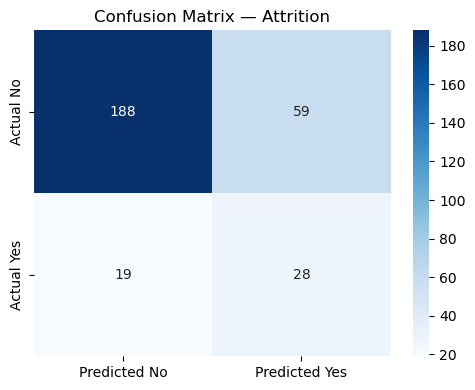

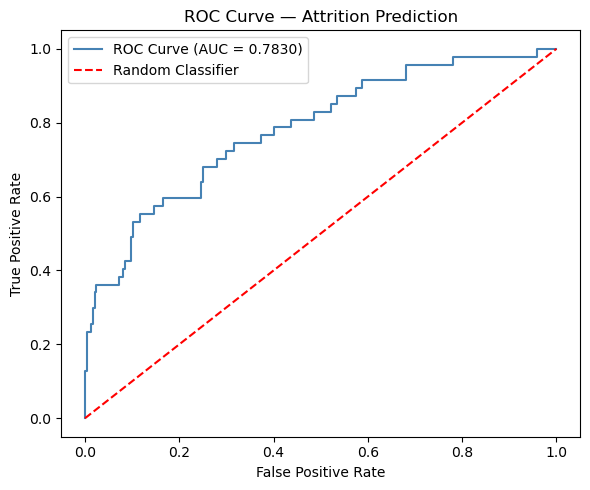


Top 10 features driving attrition:
                      Feature  Coefficient
                     OverTime     0.762793
JobRole_Laboratory Technician     0.757627
            TotalWorkingYears    -0.635633
                     JobLevel     0.587620
 JobRole_Sales Representative     0.563002
             Department_Sales     0.524819
 EducationField_Life Sciences    -0.495390
      YearsSinceLastPromotion     0.486535
       EducationField_Medical    -0.459941
           NumCompaniesWorked     0.451693


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
from sklearn.preprocessing import StandardScaler

# ── 1. Define features and target ────────────────────────
X2 = df_model.drop(['MonthlyIncome', 'MonthlyIncome_log', 'Attrition'], axis=1)
y2 = df_model['Attrition']

# ── 2. Scale features ─────────────────────────────────────
scaler = StandardScaler()
X2_scaled = scaler.fit_transform(X2)

# ── 3. Train/Test split ───────────────────────────────────
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2_scaled, y2, test_size=0.2,
    random_state=42, stratify=y2)

print("Training attrition rate:", round(y2_train.mean() * 100, 2), "%")
print("Testing attrition rate :", round(y2_test.mean() * 100, 2), "%")

# ── 4. Train with class_weight to handle imbalance ────────
log_reg = LogisticRegression(class_weight='balanced',
                              max_iter=1000, random_state=42)
log_reg.fit(X2_train, y2_train)

# ── 5. Predictions ────────────────────────────────────────
y2_pred      = log_reg.predict(X2_test)
y2_pred_prob = log_reg.predict_proba(X2_test)[:, 1]

# ── 6. Evaluation ─────────────────────────────────────────
print("\nAccuracy :", round(accuracy_score(y2_test, y2_pred) * 100, 2), "%")
print("AUC-ROC  :", round(roc_auc_score(y2_test, y2_pred_prob), 4))
print("\nClassification Report:")
print(classification_report(y2_test, y2_pred,
                             target_names=['No Attrition', 'Attrition']))

# ── 7. Confusion Matrix ───────────────────────────────────
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y2_test, y2_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No',    'Actual Yes'])
plt.title('Confusion Matrix — Attrition')
plt.tight_layout()
plt.show()

# ── 8. ROC Curve ──────────────────────────────────────────
fpr, tpr, _ = roc_curve(y2_test, y2_pred_prob)
auc_score   = roc_auc_score(y2_test, y2_pred_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='steelblue',
         label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'r--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Attrition Prediction')
plt.legend()
plt.tight_layout()
plt.show()

# ── 9. Top 10 attrition drivers ───────────────────────────
coef_df2 = pd.DataFrame({
    'Feature'    : X2.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nTop 10 features driving attrition:")
print(coef_df2.head(10).to_string(index=False))

         WORKFORCE RISK SUMMARY
  Total Employees        : 1470
  Critical Risk          : 110 employees
  High Risk              : 231 employees
  Underpaid employees    : 471 employees
  Avg Attrition Risk     : 36.1%
  Avg Salary Gap         : $-85

🔴 CRITICAL EMPLOYEES — Underpaid + High Attrition Risk:
            Department               JobRole  JobLevel  ActualSalary  PredictedSalary  SalaryGap  AttritionRisk%
Research & Development Laboratory Technician         1          2340           2696.0      356.0            99.1
                 Sales  Sales Representative         1          1118           2260.0     1142.0            97.8
Research & Development Laboratory Technician         1          2028           2753.0      725.0            97.6
                 Sales  Sales Representative         1          1675           2269.0      594.0            97.4
Research & Development    Research Scientist         1          2313           2824.0      511.0            97.0
             

/var/folders/n2/2z1lpcqn3dx8ywr6258cvn4w0000gn/T/ipykernel_4794/696182316.py:98: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/n2/2z1lpcqn3dx8ywr6258cvn4w0000gn/T/ipykernel_4794/696182316.py:98: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/n2/2z1lpcqn3dx8ywr6258cvn4w0000gn/T/ipykernel_4794/696182316.py:98: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/n2/2z1lpcqn3dx8ywr6258cvn4w0000gn/T/ipykernel_4794/696182316.py:98: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPyth

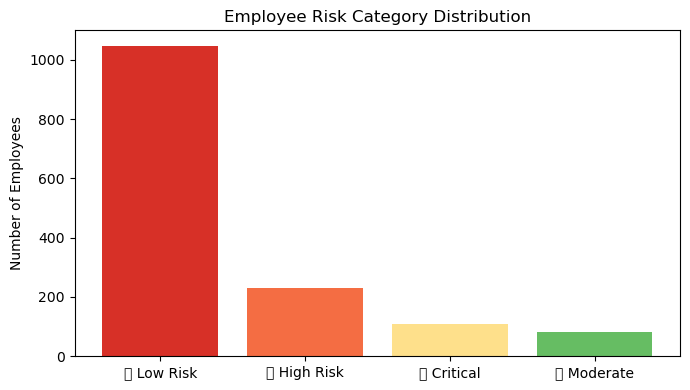

/var/folders/n2/2z1lpcqn3dx8ywr6258cvn4w0000gn/T/ipykernel_4794/696182316.py:120: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/n2/2z1lpcqn3dx8ywr6258cvn4w0000gn/T/ipykernel_4794/696182316.py:120: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/n2/2z1lpcqn3dx8ywr6258cvn4w0000gn/T/ipykernel_4794/696182316.py:120: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/n2/2z1lpcqn3dx8ywr6258cvn4w0000gn/T/ipykernel_4794/696182316.py:120: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


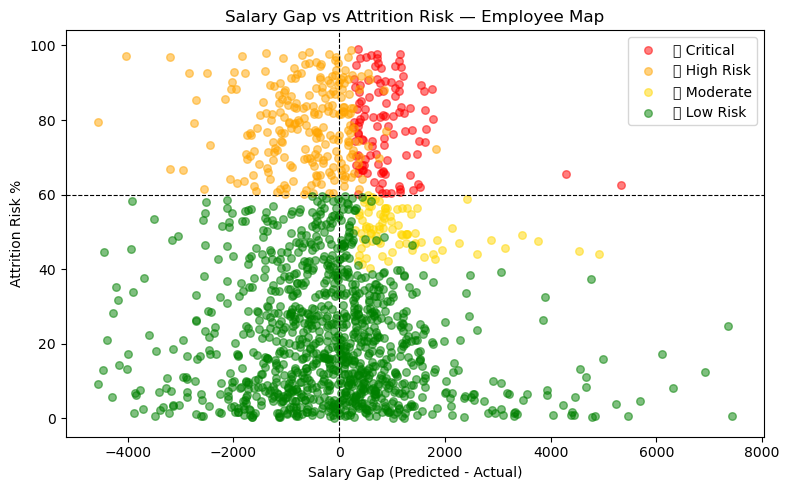

In [9]:
# ── 1. Get predictions from both models ──────────────────
# Linear Regression — predicted salary
X_all = df_model.drop(['MonthlyIncome', 'MonthlyIncome_log', 'Attrition'], axis=1)
predicted_log_salary = lr.predict(X_all)
predicted_salary     = np.exp(predicted_log_salary)

# Logistic Regression — attrition probability
X_all_scaled         = scaler.transform(X_all)
attrition_prob       = log_reg.predict_proba(X_all_scaled)[:, 1]

# ── 2. Build the combined table ───────────────────────────
risk_table = pd.DataFrame({
    'Age'               : df['Age'],
    'Department'        : df['Department'],
    'JobRole'           : df['JobRole'],
    'JobLevel'          : df['JobLevel'],
    'ActualSalary'      : df['MonthlyIncome'],
    'PredictedSalary'   : predicted_salary.round(0),
    'SalaryGap'         : (predicted_salary - df['MonthlyIncome']).round(0),
    'AttritionRisk%'    : (attrition_prob * 100).round(1),
    'ActualAttrition'   : df['Attrition']
})

# ── 3. Add Underpaid flag ─────────────────────────────────
# Underpaid = actual salary is more than 10% below predicted
risk_table['Underpaid'] = risk_table['SalaryGap'] > (
    risk_table['PredictedSalary'] * 0.10)

# ── 4. Add Risk Category ──────────────────────────────────
def categorize_risk(row):
    if row['AttritionRisk%'] >= 60 and row['Underpaid']:
        return '🔴 Critical'
    elif row['AttritionRisk%'] >= 60 and not row['Underpaid']:
        return '🟠 High Risk'
    elif row['AttritionRisk%'] >= 40 and row['Underpaid']:
        return '🟡 Moderate'
    else:
        return '🟢 Low Risk'

risk_table['RiskCategory'] = risk_table.apply(categorize_risk, axis=1)

# ── 5. Summary stats ──────────────────────────────────────
print("=" * 55)
print("         WORKFORCE RISK SUMMARY")
print("=" * 55)
print(f"  Total Employees        : {len(risk_table)}")
print(f"  Critical Risk          : "
      f"{(risk_table['RiskCategory'] == '🔴 Critical').sum()}"
      f" employees")
print(f"  High Risk              : "
      f"{(risk_table['RiskCategory'] == '🟠 High Risk').sum()}"
      f" employees")
print(f"  Underpaid employees    : "
      f"{risk_table['Underpaid'].sum()} employees")
print(f"  Avg Attrition Risk     : "
      f"{risk_table['AttritionRisk%'].mean():.1f}%")
print(f"  Avg Salary Gap         : "
      f"${risk_table['SalaryGap'].mean():,.0f}")
print("=" * 55)

# ── 6. Show Critical employees ────────────────────────────
print("\n🔴 CRITICAL EMPLOYEES — Underpaid + High Attrition Risk:")
critical = risk_table[risk_table['RiskCategory'] == '🔴 Critical']\
    .sort_values('AttritionRisk%', ascending=False)\
    [['Department', 'JobRole', 'JobLevel', 
      'ActualSalary', 'PredictedSalary', 
      'SalaryGap', 'AttritionRisk%']].head(10)
print(critical.to_string(index=False))

# ── 7. Risk by Department ─────────────────────────────────
print("\n📊 RISK BREAKDOWN BY DEPARTMENT:")
dept_risk = risk_table.groupby('Department').agg(
    AvgAttritionRisk  = ('AttritionRisk%', 'mean'),
    CriticalCount     = ('RiskCategory', 
                         lambda x: (x == '🔴 Critical').sum()),
    AvgSalaryGap      = ('SalaryGap', 'mean'),
    TotalEmployees    = ('Age', 'count')
).round(1)
print(dept_risk.to_string())

# ── 8. Risk by Job Role ───────────────────────────────────
print("\n📊 RISK BREAKDOWN BY JOB ROLE:")
role_risk = risk_table.groupby('JobRole').agg(
    AvgAttritionRisk  = ('AttritionRisk%', 'mean'),
    CriticalCount     = ('RiskCategory', 
                         lambda x: (x == '🔴 Critical').sum()),
    AvgSalaryGap      = ('SalaryGap', 'mean')
).round(1).sort_values('AvgAttritionRisk', ascending=False)
print(role_risk.to_string())

# ── 9. Visualize Risk Categories ──────────────────────────
plt.figure(figsize=(7, 4))
risk_counts = risk_table['RiskCategory'].value_counts()
colors = ['#d73027', '#f46d43', '#fee08b', '#66bd63']
plt.bar(risk_counts.index, risk_counts.values, color=colors)
plt.title('Employee Risk Category Distribution')
plt.ylabel('Number of Employees')
plt.tight_layout()
plt.show()

# ── 10. Salary Gap vs Attrition Risk scatter ─────────────
plt.figure(figsize=(8, 5))
colors_map = {
    '🔴 Critical' : 'red',
    '🟠 High Risk' : 'orange',
    '🟡 Moderate'  : 'gold',
    '🟢 Low Risk'  : 'green'
}
for category, color in colors_map.items():
    subset = risk_table[risk_table['RiskCategory'] == category]
    plt.scatter(subset['SalaryGap'], subset['AttritionRisk%'],
                c=color, label=category, alpha=0.5, s=30)

plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.axhline(60, color='black', linestyle='--', linewidth=0.8)
plt.xlabel('Salary Gap (Predicted - Actual)')
plt.ylabel('Attrition Risk %')
plt.title('Salary Gap vs Attrition Risk — Employee Map')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# ── Create a sample employee ──────────────────────────────
sample = pd.DataFrame([{
    'Age'                               : 28,
    'BusinessTravel'                    : 2,   # Travel_Rarely
    'DailyRate'                         : 500,
    'DistanceFromHome'                  : 10,
    'Education'                         : 2,
    'EnvironmentSatisfaction'           : 2,
    'HourlyRate'                        : 50,
    'JobInvolvement'                    : 2,
    'JobLevel'                          : 1,
    'JobSatisfaction'                   : 2,
    'MonthlyRate'                       : 10000,
    'NumCompaniesWorked'                : 3,
    'OverTime'                          : 1,   # Yes
    'PercentSalaryHike'                 : 11,
    'PerformanceRating'                 : 3,
    'RelationshipSatisfaction'          : 2,
    'StockOptionLevel'                  : 0,
    'TotalWorkingYears'                 : 5,
    'TrainingTimesLastYear'             : 2,
    'WorkLifeBalance'                   : 2,
    'YearsAtCompany'                    : 2,
    'YearsInCurrentRole'                : 1,
    'YearsSinceLastPromotion'           : 2,
    'YearsWithCurrManager'              : 1,
    # Department — Sales
    'Department_Research & Development' : 0,
    'Department_Sales'                  : 1,
    # Education Field
    'EducationField_Life Sciences'      : 0,
    'EducationField_Marketing'          : 1,
    'EducationField_Medical'            : 0,
    'EducationField_Other'              : 0,
    'EducationField_Technical Degree'   : 0,
    # Gender
    'Gender_Male'                       : 1,
    # Job Role — Sales Representative
    'JobRole_Human Resources'           : 0,
    'JobRole_Laboratory Technician'     : 0,
    'JobRole_Manager'                   : 0,
    'JobRole_Manufacturing Director'    : 0,
    'JobRole_Research Director'         : 0,
    'JobRole_Research Scientist'        : 0,
    'JobRole_Sales Executive'           : 0,
    'JobRole_Sales Representative'      : 1,
    # Marital Status
    'MaritalStatus_Married'             : 0,
    'MaritalStatus_Single'              : 1,
}])

# ── Linear Regression — Salary Prediction ────────────────
pred_log_salary = lr.predict(sample)[0]
pred_salary     = np.exp(pred_log_salary)

# ── Logistic Regression — Attrition Prediction ───────────
sample_scaled   = scaler.transform(sample)
attrition_prob  = log_reg.predict_proba(sample_scaled)[0][1] * 100
attrition_pred  = log_reg.predict(sample_scaled)[0]
attrition_label = "YES — Will Quit 🚨" if attrition_pred == 1 else "NO — Will Stay ✅"

# ── Risk Category ─────────────────────────────────────────
if attrition_prob >= 60:
    risk = "🔴 CRITICAL"
elif attrition_prob >= 40:
    risk = "🟠 HIGH RISK"
else:
    risk = "🟢 LOW RISK"

# ── Print Results ─────────────────────────────────────────
print("=" * 50)
print("         EMPLOYEE PROFILE")
print("=" * 50)
print(f"  Age                  : 28")
print(f"  Department           : Sales")
print(f"  Job Role             : Sales Representative")
print(f"  Job Level            : 1 (Junior)")
print(f"  Experience           : 5 years")
print(f"  OverTime             : YES")
print(f"  Job Satisfaction     : 2/4 (Low)")
print(f"  Single               : YES")
print(f"  Years since Promotion: 2 years")
print(f"  No. of companies     : 3")
print("=" * 50)
print("         MODEL PREDICTIONS")
print("=" * 50)
print(f"  Predicted Salary     : ${pred_salary:,.0f}/month")
print(f"  Attrition Risk       : {attrition_prob:.1f}%")
print(f"  Will this person quit: {attrition_label}")
print(f"  Risk Category        : {risk}")
print("=" * 50)

         EMPLOYEE PROFILE
  Age                  : 28
  Department           : Sales
  Job Role             : Sales Representative
  Job Level            : 1 (Junior)
  Experience           : 5 years
  OverTime             : YES
  Job Satisfaction     : 2/4 (Low)
  Single               : YES
  Years since Promotion: 2 years
  No. of companies     : 3
         MODEL PREDICTIONS
  Predicted Salary     : $2,481/month
  Attrition Risk       : 99.6%
  Will this person quit: YES — Will Quit 🚨
  Risk Category        : 🔴 CRITICAL
